#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [100]:
import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import RobustScaler

from haversine import haversine, Unit
from sklearn.impute import KNNImputer
import math

import warnings

In [101]:
warnings.filterwarnings("ignore")

In [102]:
### carga datos del dataset 
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [103]:
columnas = ['key', 'pickup_datetime', 'passenger_count', 
                   'pickup_longitude', 'pickup_latitude', 
                   'dropoff_longitude', 'dropoff_latitude']
columna_target = 'fare_amount'

# Crear X e y iniciales
X = df[columnas].copy()
y = df[columna_target].copy()

# División inicial train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=None)

In [104]:
# Definir los límites geográficos de Nueva York (Manhattan y áreas cercanas)
NY_COORDENADAS = {
    'min_lat': 40.4774,      # Sur de Manhattan
    'max_lat': 40.9176,      # Norte de Manhattan/Bronx
    'min_lon': -74.2591,     # Oeste de Manhattan
    'max_lon': -73.7004      # Este de Brooklyn/Queens
}

In [105]:
def limpiar_coordenadas(X_train, X_test, y_train, y_test):
    """
    Limpia y filtra las coordenadas de Nueva York 
    Modifica y_train, y_test para mantener consistencia
    """

    def set_invalid_to_nan(df, bounds):
        df.loc[(df['pickup_latitude'] < bounds['min_lat']) | (df['pickup_latitude'] > bounds['max_lat']), 'pickup_latitude'] = np.nan
        df.loc[(df['pickup_longitude'] < bounds['min_lon']) | (df['pickup_longitude'] > bounds['max_lon']), 'pickup_longitude'] = np.nan
        df.loc[(df['dropoff_latitude'] < bounds['min_lat']) | (df['dropoff_latitude'] > bounds['max_lat']), 'dropoff_latitude'] = np.nan
        df.loc[(df['dropoff_longitude'] < bounds['min_lon']) | (df['dropoff_longitude'] > bounds['max_lon']), 'dropoff_longitude'] = np.nan
        return df

    # Copiar datasets
    X_train_filtered = X_train.copy()
    y_train_filtered = y_train.copy()

    X_test_filtered = X_test.copy()
    y_test_filtered = y_test.copy()

    # Establecer coordenadas inválidas a NaN
    X_train_filtered = set_invalid_to_nan(X_train_filtered, NY_COORDENADAS)
    X_test_filtered = set_invalid_to_nan(X_test_filtered, NY_COORDENADAS)

    # Imputar con KNN
    coord_cols = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
    imputer = KNNImputer(n_neighbors=5)

    X_train_filtered[coord_cols] = imputer.fit_transform(X_train_filtered[coord_cols])
    X_test_filtered[coord_cols] = imputer.transform(X_test_filtered[coord_cols])
    # Calcular distancia de viaje 
    def calculate_distance(row):
        return haversine(
                (row['pickup_latitude'], row['pickup_longitude']),
                (row['dropoff_latitude'], row['dropoff_longitude']),
                unit=Unit.KILOMETERS)


    # Para TRAIN - eliminar distancia 0
    X_train_filtered['distance_km'] = X_train_filtered.apply(calculate_distance, axis=1)
    zero_distance_train = X_train_filtered['distance_km'] == 0
    if zero_distance_train.sum() > 0:
        X_train_filtered = X_train_filtered[~zero_distance_train].copy()
        y_train_filtered = y_train_filtered[~zero_distance_train].copy()

    # Para TEST - eliminar distancia 0
    X_test_filtered['distance_km'] = X_test_filtered.apply(calculate_distance, axis=1)      # REVISAR SI HACE FALTA APLICAR A TEST!!!!!
    zero_distance_test = X_test_filtered['distance_km'] == 0
    if zero_distance_test.sum() > 0:
        X_test_filtered = X_test_filtered[~zero_distance_test].copy()
        y_test_filtered = y_test_filtered[~zero_distance_test].copy()

    return X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered

In [106]:
def procesar_datos_temporales_y_limpieza(X_train, X_test, y_train, y_test):
    
    # PROCESAR CARACTERÍSTICAS TEMPORALES PARA TRAIN
    X_train_copy = X_train.copy()
    
    # Convertir a datetime (manejar formato UTC)
    X_train_copy['pickup_datetime'] = pd.to_datetime(X_train_copy['pickup_datetime'].str.replace(' UTC', ''), utc=True)

    # Extraer día de la semana (0=Lunes, 6=Domingo)
    X_train_copy['day_week_num'] = X_train_copy['pickup_datetime'].dt.dayofweek

    # Encoding circular para día de la semana
    sin_col = f"day_week_num_sin"
    cos_col = f"day_week_num_cos"
    X_train_copy[sin_col] = np.sin(2 * np.pi * X_train_copy['day_week_num'] / 7)
    X_train_copy[cos_col] = np.cos(2 * np.pi * X_train_copy['day_week_num'] / 7)

    # Extraer hora
    X_train_copy['hora'] = X_train_copy['pickup_datetime'].dt.hour

    # Crear categorías de período del día
    etiquetas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
    bins = [0, 6, 12, 18, 24]
    X_train_copy['period_of_the_day'] = pd.cut(X_train_copy['hora'], bins=bins,
                                            labels=etiquetas, right=False, include_lowest=True)

    # Encoding circular para hora
    sin_col_hora = f"hora_sin"
    cos_col_hora = f"hora_cos"
    X_train_copy[sin_col_hora] = np.sin(2 * np.pi * X_train_copy['hora'] / 24)
    X_train_copy[cos_col_hora] = np.cos(2 * np.pi * X_train_copy['hora'] / 24)

    # PROCESAR CARACTERÍSTICAS TEMPORALES PARA TEST
    X_test_copy = X_test.copy()
    
    # Convertir a datetime 
    X_test_copy['pickup_datetime'] = pd.to_datetime(X_test_copy['pickup_datetime'].str.replace(' UTC', ''), utc=True)

    # Extraer día de la semana (0=Lunes, 6=Domingo)
    X_test_copy['day_week_num'] = X_test_copy['pickup_datetime'].dt.dayofweek

    # Encoding circular para día de la semana
    sin_col = f"day_week_num_sin"
    cos_col = f"day_week_num_cos"
    X_test_copy[sin_col] = np.sin(2 * np.pi * X_test_copy['day_week_num'] / 7)
    X_test_copy[cos_col] = np.cos(2 * np.pi * X_test_copy['day_week_num'] / 7)

    # Extraer hora
    X_test_copy['hora'] = X_test_copy['pickup_datetime'].dt.hour

    # Crear categorías de período del día
    X_test_copy['period_of_the_day'] = pd.cut(X_test_copy['hora'], bins=bins,
                                            labels=etiquetas, right=False, include_lowest=True)

    # Encoding circular para hora
    X_test_copy[sin_col_hora] = np.sin(2 * np.pi * X_test_copy['hora'] / 24)
    X_test_copy[cos_col_hora] = np.cos(2 * np.pi * X_test_copy['hora'] / 24)
    
    # LIMPIEZA DE OUTLIERS - PASAJEROS (TRAIN)
    valid_passengers_mask_train = X_train_copy['passenger_count'] <= 10
    X_train_filtered = X_train_copy[valid_passengers_mask_train].copy()
    y_train_filtered = y_train[valid_passengers_mask_train].copy()

    # LIMPIEZA DE OUTLIERS - FARE_AMOUNT (<0) (TRAIN)
    initial_rows_fare_train = len(X_train_filtered)
    valid_fare_mask_train = y_train_filtered >= 0
    X_train_final = X_train_filtered[valid_fare_mask_train].copy()
    y_train_final = y_train_filtered[valid_fare_mask_train].copy()
    
    # LIMPIEZA DE OUTLIERS - PASAJEROS (TEST)
    valid_passengers_mask_test = X_test_copy['passenger_count'] <= 10          # REVISAR SI HACE FALTA APLICAR A TEST!!!!!
    X_test_filtered = X_test_copy[valid_passengers_mask_test].copy()
    y_test_filtered = y_test[valid_passengers_mask_test].copy()

    # LIMPIEZA DE OUTLIERS - FARE_AMOUNT (<0) (TEST)
    initial_rows_fare_test = len(X_test_filtered)                       
    valid_fare_mask_test = y_test_filtered >= 0
    X_test_final = X_test_filtered[valid_fare_mask_test].copy()
    y_test_final = y_test_filtered[valid_fare_mask_test].copy()


    return X_train_final, X_test_final, y_train_final, y_test_final

In [107]:
# LIMPIEZA DE COORDENADAS
X_train, X_test, y_train, y_test = limpiar_coordenadas(X_train, X_test, y_train, y_test)

# PROCESAMIENTO TEMPORAL
X_train, X_test, y_train, y_test = procesar_datos_temporales_y_limpieza(X_train, X_test, y_train, y_test)

In [108]:
X_train.head()

,key,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,day_week_num,day_week_num_sin,day_week_num_cos,hora,period_of_the_day,hora_sin,hora_cos
153248,17778666,2009-11-19 21:59:00+00:00,1,-73.978585,40.748388,-73.976913,40.784958,4.068841,3,0.433884,-0.900969,21,Noche,-0.707107,0.707107
67802,54334677,2013-02-27 22:29:15+00:00,1,-73.978198,40.752533,-73.909752,40.874372,14.721602,2,0.974928,-0.222521,22,Noche,-0.500000,0.866025
148889,11815656,2014-06-01 08:48:00+00:00,1,-73.994242,40.751227,-73.999432,40.762037,1.279042,6,-0.781831,0.623490,8,Mañana,0.866025,-0.500000
103093,28734805,2010-07-10 23:10:00+00:00,2,-73.951705,40.778330,-73.956050,40.777560,0.375743,5,-0.974928,-0.222521,23,Noche,-0.258819,0.965926
104681,54482655,2013-09-29 13:36:00+00:00,1,-73.989120,40.736932,-73.782890,40.643947,20.229724,6,-0.781831,0.623490,13,Tarde,-0.258819,-0.965926


In [109]:
X_train.describe()

,key,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,day_week_num,day_week_num_sin,day_week_num_cos,hora,hora_sin,hora_cos
count,1.584310e+05,158431.000000,158431.000000,158431.000000,158431.000000,158431.000000,158431.000000,158431.000000,158431.000000,158431.000000,158431.000000,158431.000000,158431.000000
mean,2.770837e+07,1.682998,-73.975610,40.750788,-73.974709,40.751112,3.282479,3.049826,-0.000718,-0.043562,13.481377,-0.194018,-0.069160
std,1.602997e+07,1.306624,0.034043,0.026572,0.033491,0.030300,3.555008,1.947173,0.711534,0.701304,6.516305,0.668758,0.714383
min,1.000000e+00,0.000000,-74.250648,40.492457,-74.250648,40.486242,0.000084,0.000000,-0.974928,-0.900969,0.000000,-1.000000,-1.000000
25%,1.379082e+07,1.000000,-73.992076,40.736913,-73.991442,40.735917,1.236959,1.000000,-0.781831,-0.900969,9.000000,-0.866025,-0.707107
50%,2.774789e+07,1.000000,-73.981881,40.752605,-73.980122,40.753045,2.140719,3.000000,0.000000,-0.222521,14.000000,-0.258819,-0.258819
75%,4.155158e+07,2.000000,-73.968967,40.767107,-73.966067,40.768040,3.877736,5.000000,0.781831,0.623490,19.000000,0.500000,0.707107
max,5.542357e+07,6.000000,-73.702735,40.917048,-73.700650,40.916956,35.341909,6.000000,0.974928,1.000000,23.000000,1.000000,1.000000


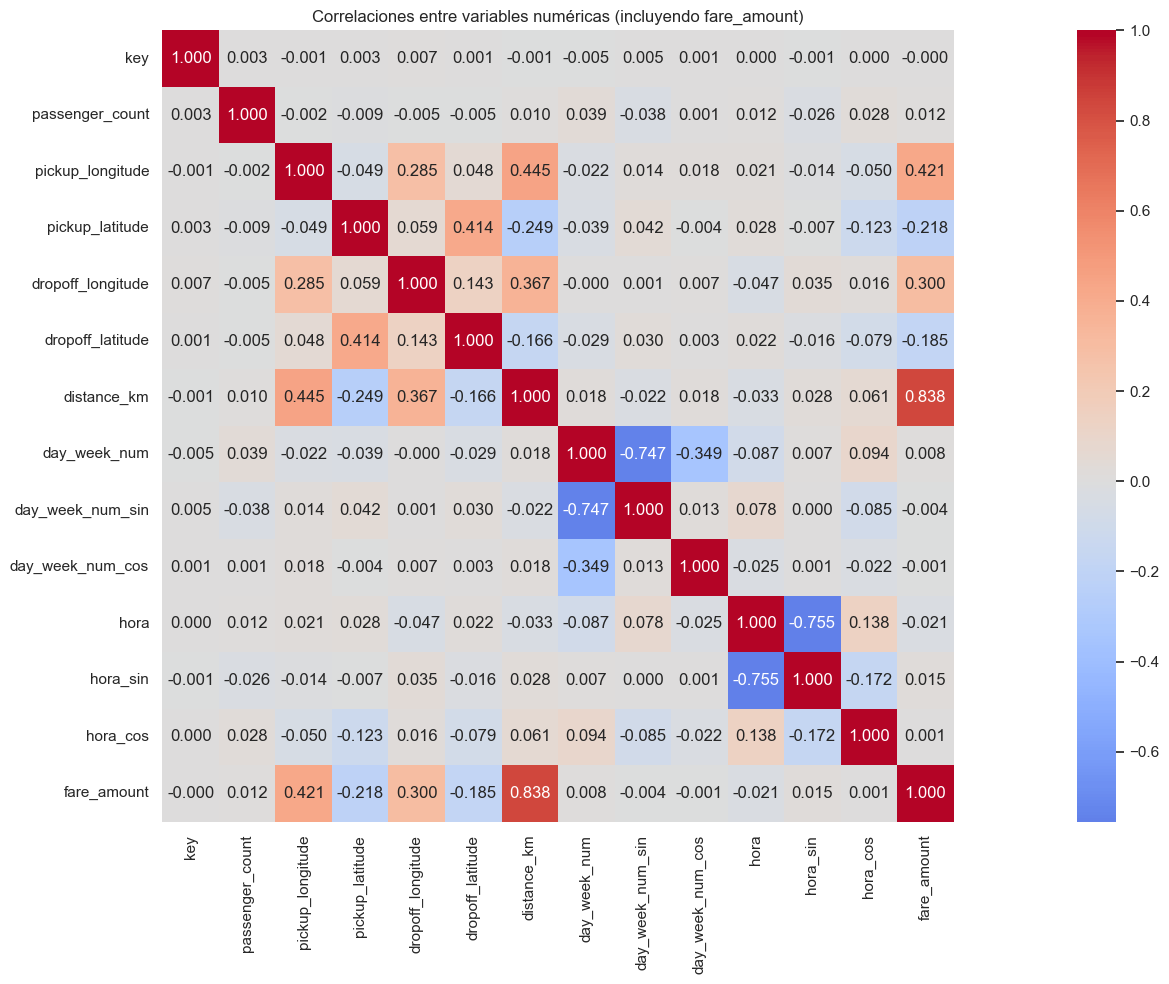

In [110]:
# Crear dataframe temporal que incluya y_train para el análisis de correlación
df_train_temp = X_train.copy()
df_train_temp['fare_amount'] = y_train

# Seleccionar solo columnas numéricas para la matriz de correlación
numeric_cols = df_train_temp.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

# Visualización de correlaciones
plt.figure(figsize=(25, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Correlaciones entre variables numéricas (incluyendo fare_amount)')
plt.tight_layout()
plt.show()

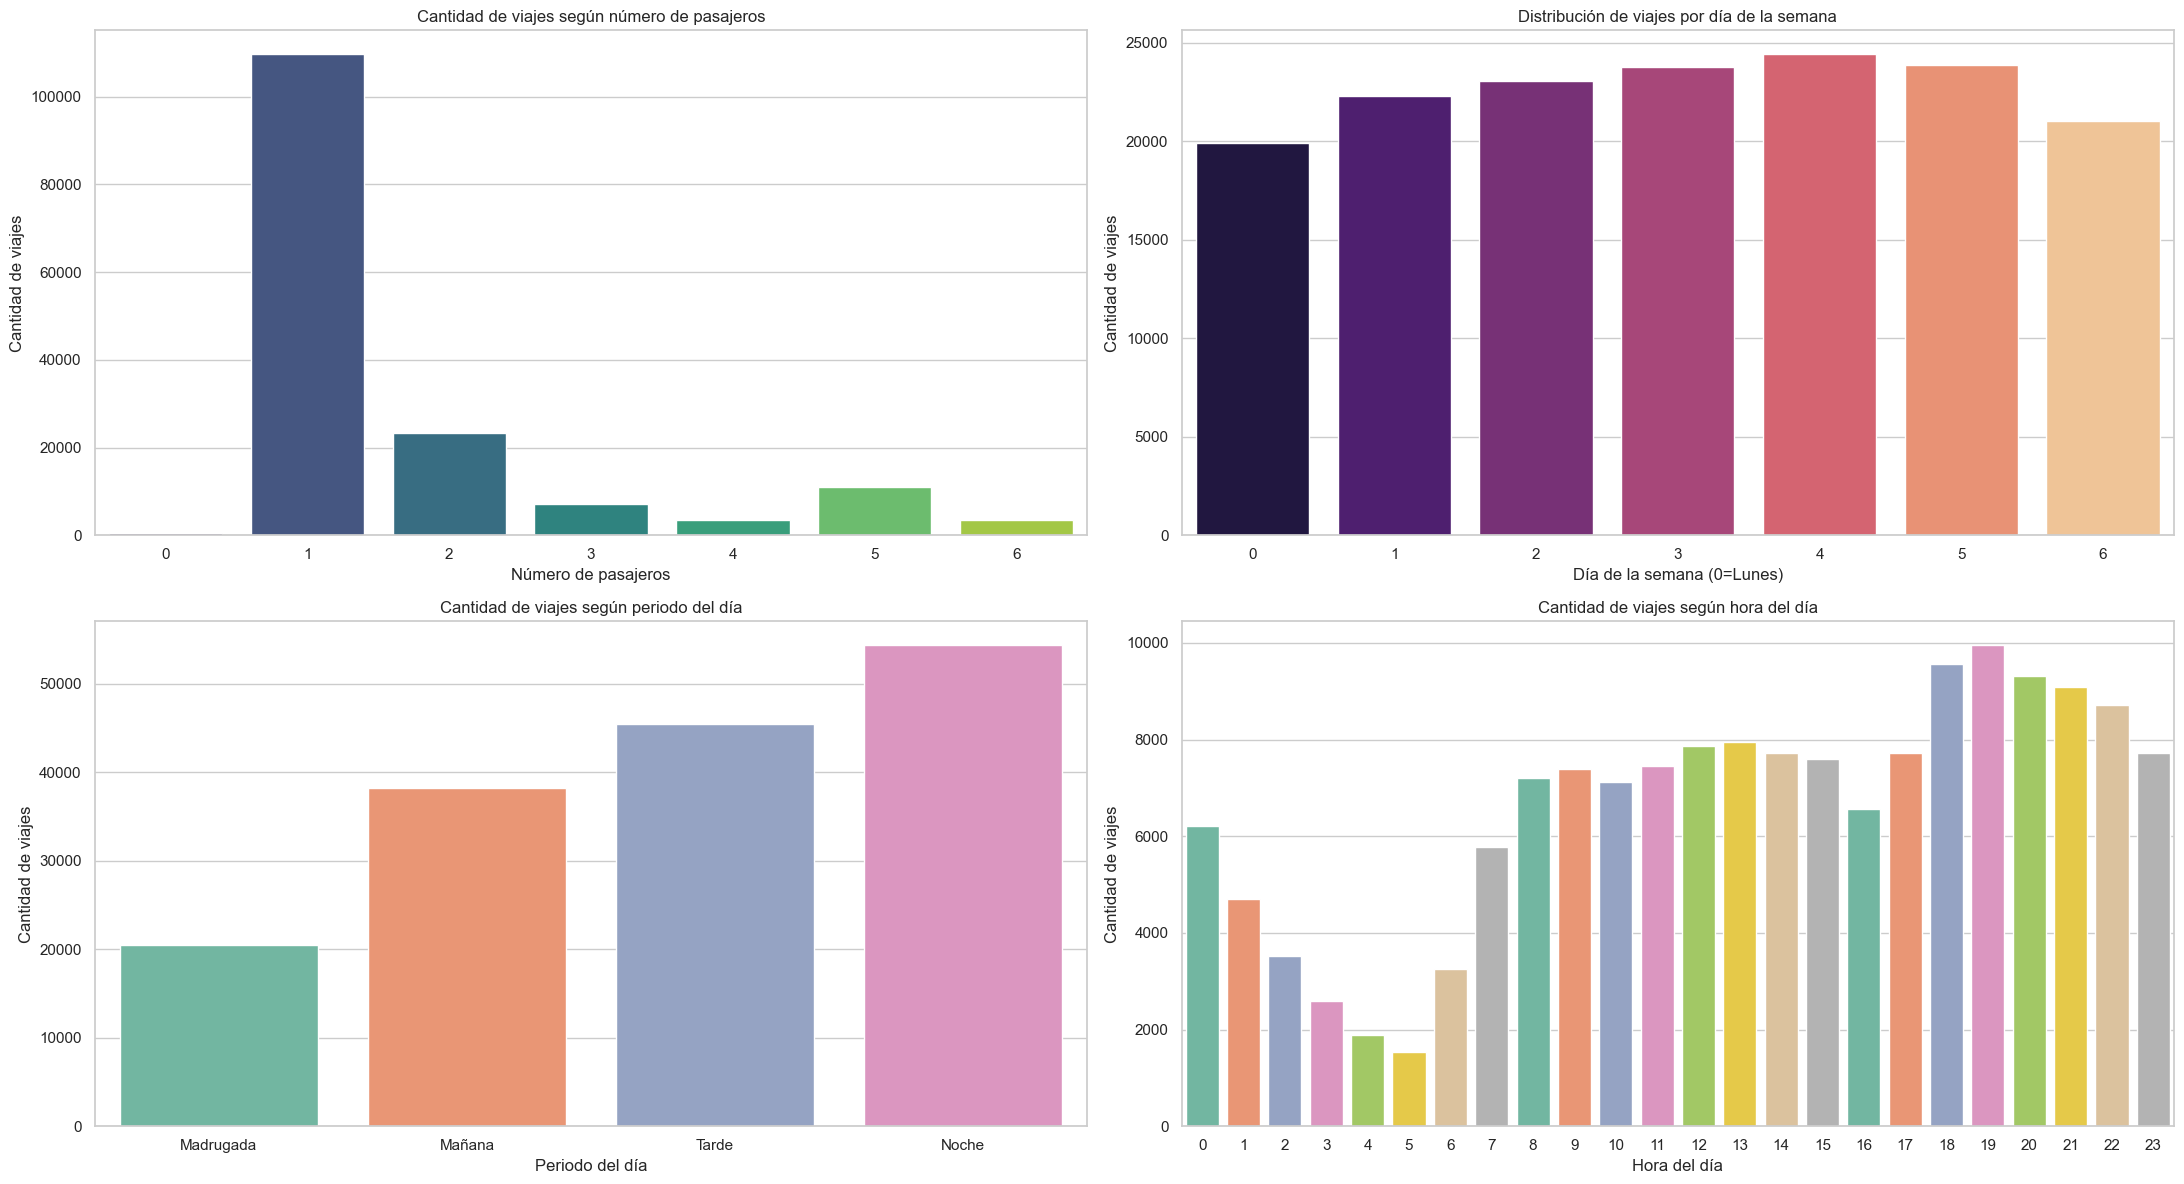

In [111]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Conteo de viajes por cantidad de pasajeros
sns.countplot(data=X_train, x="passenger_count", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Cantidad de viajes según número de pasajeros")
axes[0,0].set_xlabel("Número de pasajeros")
axes[0,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por día de la semana
order_days = [0, 1, 2, 3, 4, 5, 6]  # Lunes=0 ... Domingo=6
sns.countplot(data=X_train, x="day_week_num", order=order_days, ax=axes[0,1], palette="magma")
axes[0,1].set_title("Distribución de viajes por día de la semana")
axes[0,1].set_xlabel("Día de la semana (0=Lunes)")
axes[0,1].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="period_of_the_day",
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[1,0],
    palette="Set2"
)
axes[1,0].set_title("Cantidad de viajes según periodo del día")
axes[1,0].set_xlabel("Periodo del día")
axes[1,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="hora",
    ax=axes[1,1],
    palette="Set2"
)
axes[1,1].set_title("Cantidad de viajes según hora del día")
axes[1,1].set_xlabel("Hora del día")
axes[1,1].set_ylabel("Cantidad de viajes")


plt.tight_layout()
plt.show()

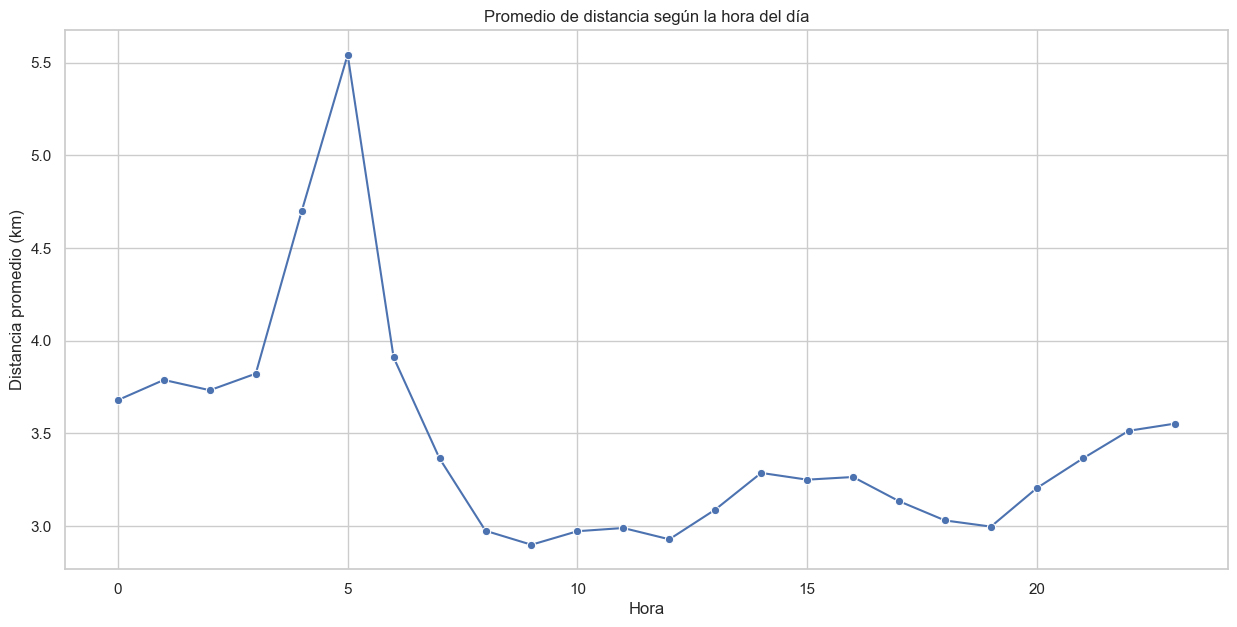

In [112]:
# Promedio de distancia según hora del día

plt.figure(figsize=(15,7))
sns.lineplot(data=X_train, x="hora", y="distance_km", estimator="mean", ci=None, marker="o")
plt.title("Promedio de distancia según la hora del día")
plt.xlabel("Hora")
plt.ylabel("Distancia promedio (km)")
plt.show()

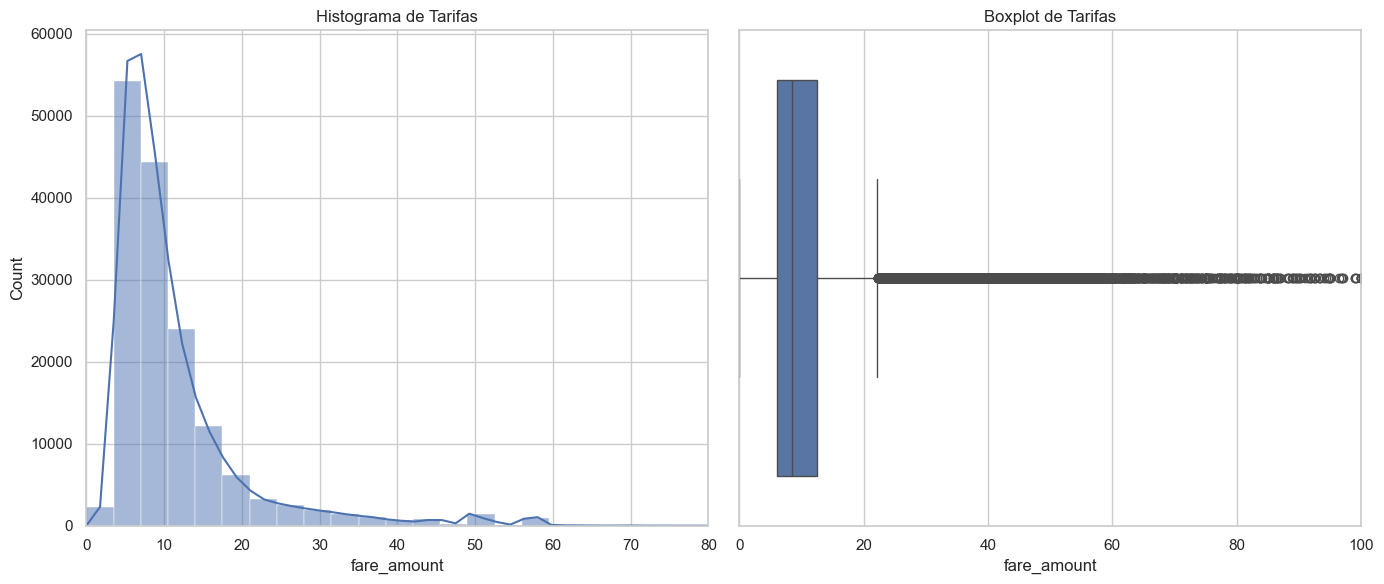

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de tarifas
sns.histplot(y_train, bins=100, kde=True, ax=axes[0])
axes[0].set_xlim(0, 80)  # límite para ver mejor la zona central
axes[0].set_title("Histograma de Tarifas")

# Boxplot de tarifas
sns.boxplot(x=y_train, ax=axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_title("Boxplot de Tarifas")

plt.tight_layout()
plt.show()

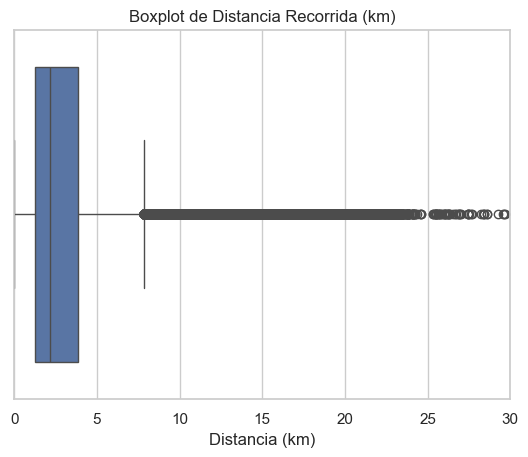

In [114]:
# Boxplot distancia
sns.boxplot(x=X_train['distance_km'])
plt.title("Boxplot de Distancia Recorrida (km)")
plt.xlabel("Distancia (km)")
plt.xlim(0, 30) 
plt.show()

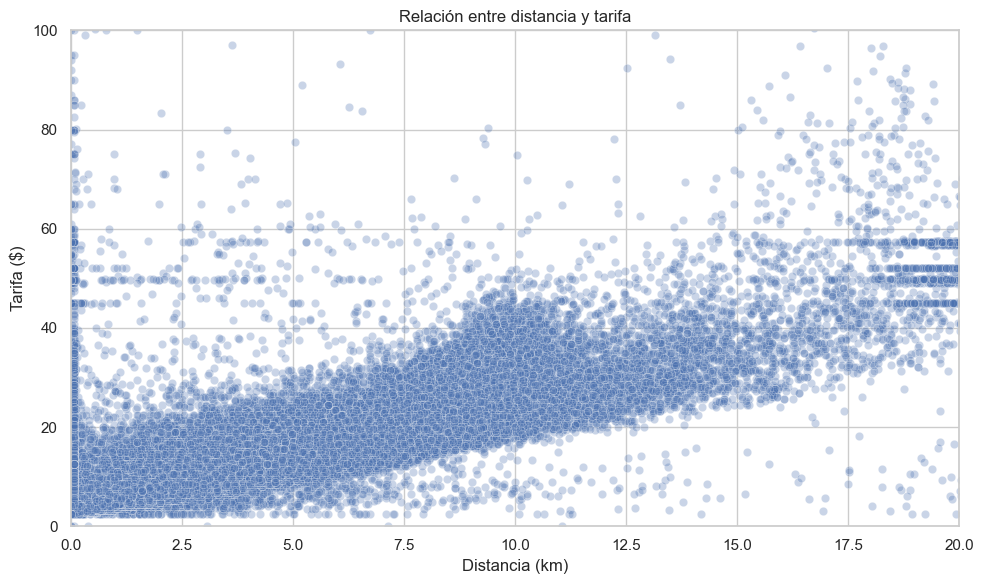

In [115]:
# Relación entre distancia y tarifa (dispersión)
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x=X_train["distance_km"], y=y_train, alpha=0.3)
plt.xlim(0, 20)   # Limitar a 20 km para evitar outliers extremos
plt.ylim(0, 100)  # Limitar a 100 dólares para evitar outliers extremos
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Tarifa ($)")
plt.tight_layout()
plt.show()

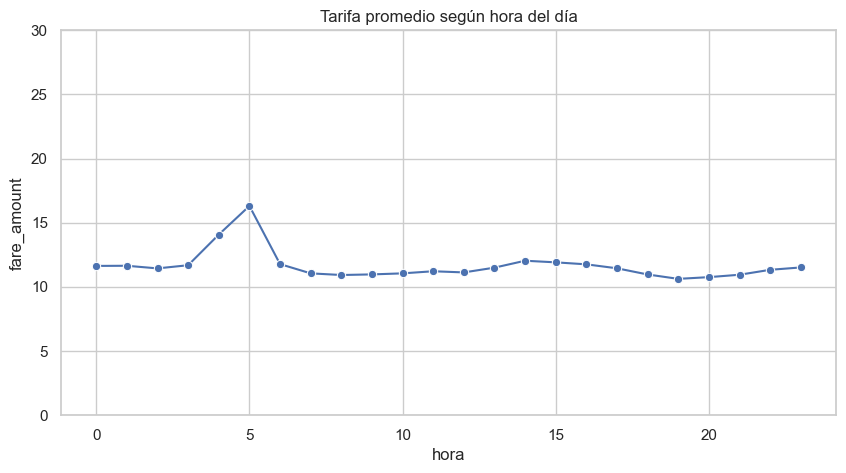

In [116]:
# Fare por hora del día

plt.figure(figsize=(10,5))
sns.lineplot(x=X_train["hora"], y=y_train, estimator="mean", errorbar=None, marker="o")
plt.ylim(0, 30)
plt.title("Tarifa promedio según hora del día")
plt.show()

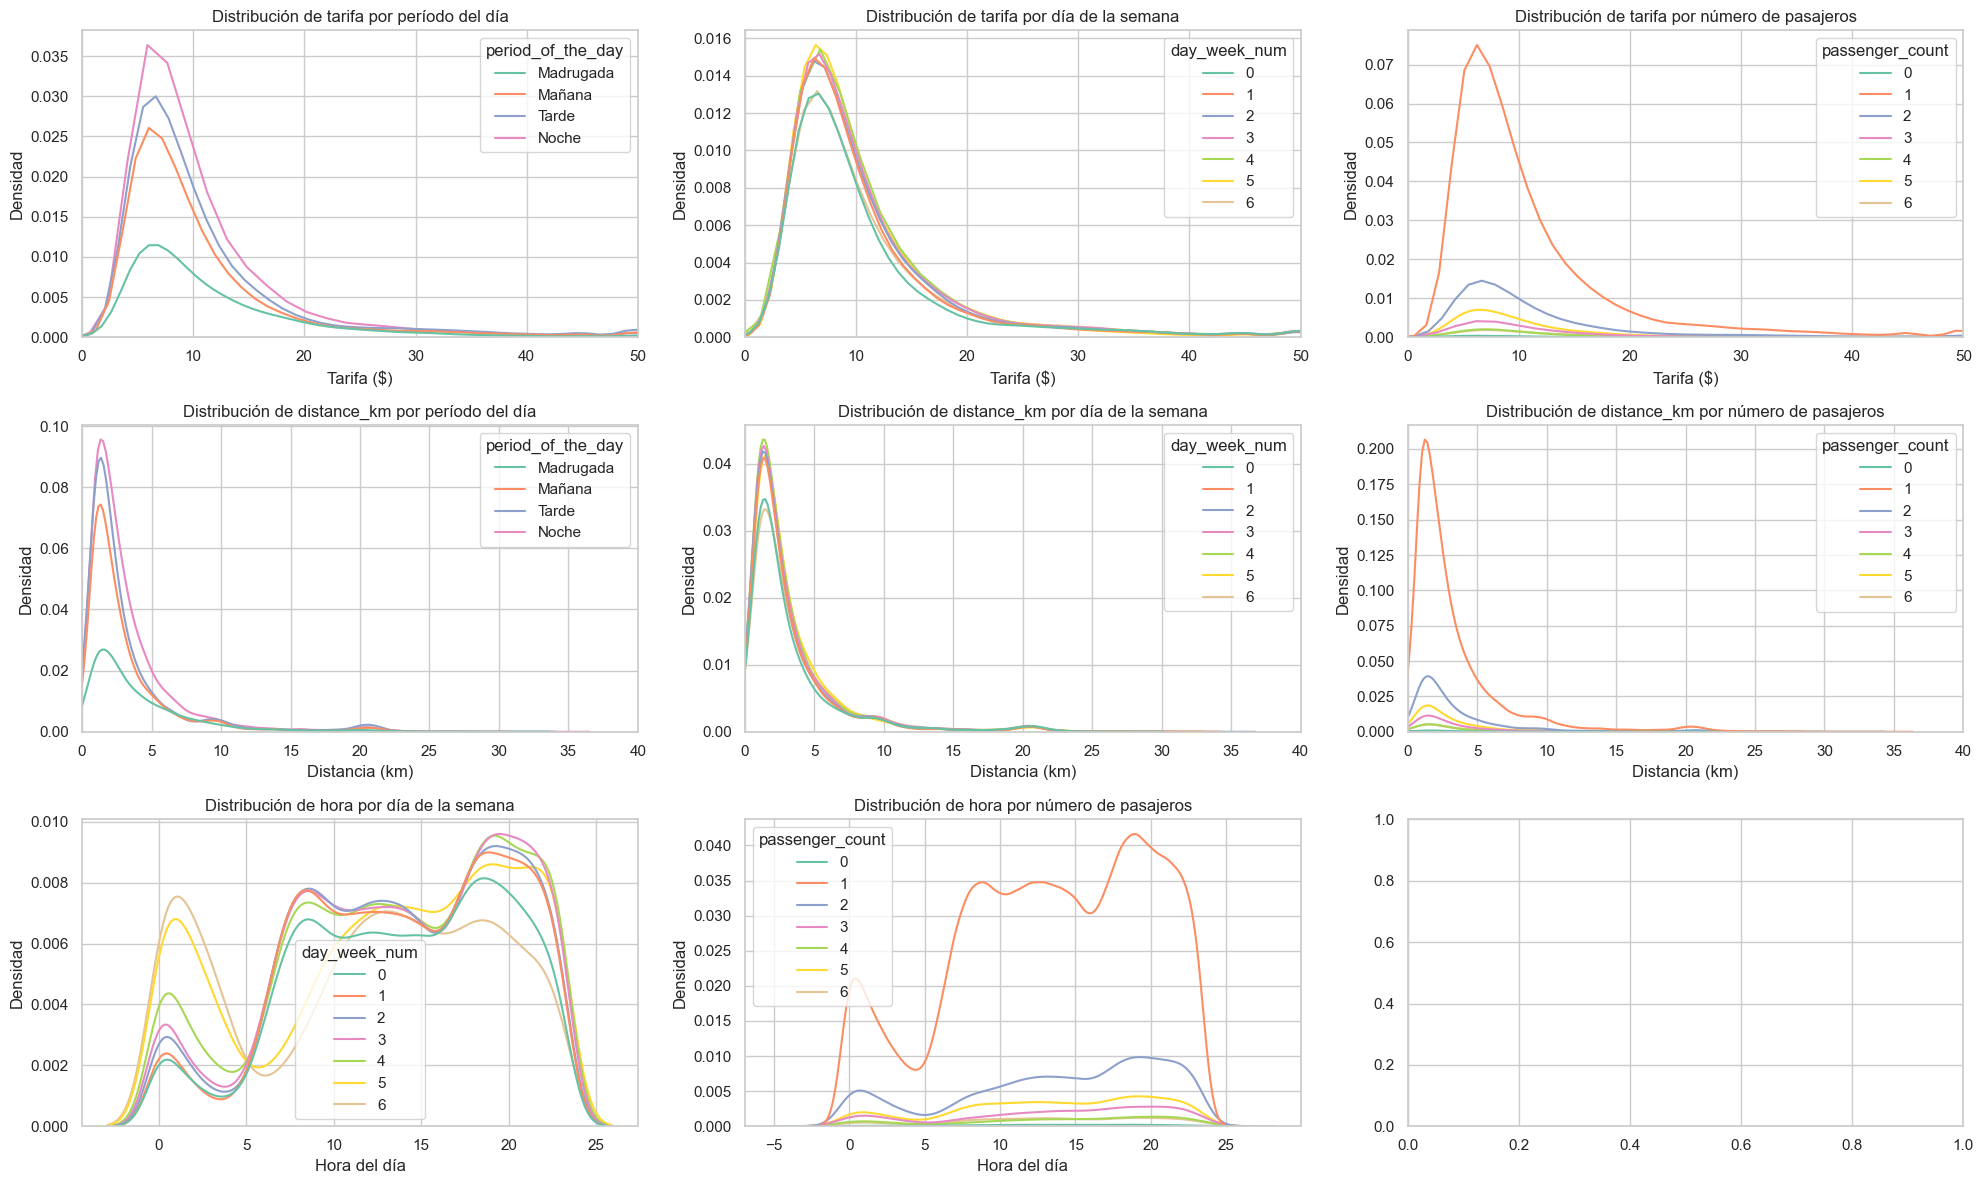

In [117]:
fig, ((ax1, ax2, ax3) ,(ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))

# Combinar X_train y y_train para los gráficos de target
data_combined = X_train.copy()
data_combined['target'] = y_train

# Gráfico 1: Distribución de la variable objetivo por período del día
sns.kdeplot(data=data_combined, x='target', hue='period_of_the_day', palette='Set2', ax=ax1)
ax1.set_xlim(0, 50)
ax1.set_title("Distribución de tarifa por período del día")
ax1.set_xlabel("Tarifa ($)")
ax1.set_ylabel("Densidad")

# Gráfico 2: Distribución de la variable objetivo por día de la semana
sns.kdeplot(data=data_combined, x='target', hue='day_week_num', palette='Set2', ax=ax2)
ax2.set_xlim(0, 50)
ax2.set_title("Distribución de tarifa por día de la semana")
ax2.set_xlabel("Tarifa ($)")
ax2.set_ylabel("Densidad")

# Gráfico 3: Distribución de la variable objetivo por número de pasajeros
sns.kdeplot(data=data_combined, x='target', hue='passenger_count', palette='Set2', ax=ax3)
ax3.set_xlim(0, 50)
ax3.set_title("Distribución de tarifa por número de pasajeros")
ax3.set_xlabel("Tarifa ($)")
ax3.set_ylabel("Densidad")

# Gráfico 4: Distribución de distance_km por período del día
sns.kdeplot(data=X_train, x='distance_km', hue='period_of_the_day', palette='Set2', ax=ax4)
ax4.set_xlim(0, 40)
ax4.set_title("Distribución de distance_km por período del día")
ax4.set_xlabel("Distancia (km)")
ax4.set_ylabel("Densidad")

# Gráfico 5: Distribución de distance_km por día de la semana
sns.kdeplot(data=X_train, x='distance_km', hue='day_week_num', palette='Set2', ax=ax5)
ax5.set_xlim(0, 40)
ax5.set_title("Distribución de distance_km por día de la semana")
ax5.set_xlabel("Distancia (km)")
ax5.set_ylabel("Densidad")

# Gráfico 6: Distribución de distance_km por número de pasajeros
sns.kdeplot(data=X_train, x='distance_km', hue='passenger_count', palette='Set2', ax=ax6)
ax6.set_xlim(0, 40)
ax6.set_title("Distribución de distance_km por número de pasajeros")
ax6.set_xlabel("Distancia (km)")
ax6.set_ylabel("Densidad")

# Gráfico 7: Distribución de hora por día de la semana
sns.kdeplot(data=X_train, x='hora', hue='day_week_num', palette='Set2', ax=ax7)
ax7.set_title("Distribución de hora por día de la semana")
ax7.set_xlabel("Hora del día")
ax7.set_ylabel("Densidad")

# Gráfico 8: Distribución de hora por número de pasajeros
sns.kdeplot(data=X_train, x='hora', hue='passenger_count', palette='Set2', ax=ax8)
ax8.set_title("Distribución de hora por número de pasajeros")
ax8.set_xlabel("Hora del día")
ax8.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

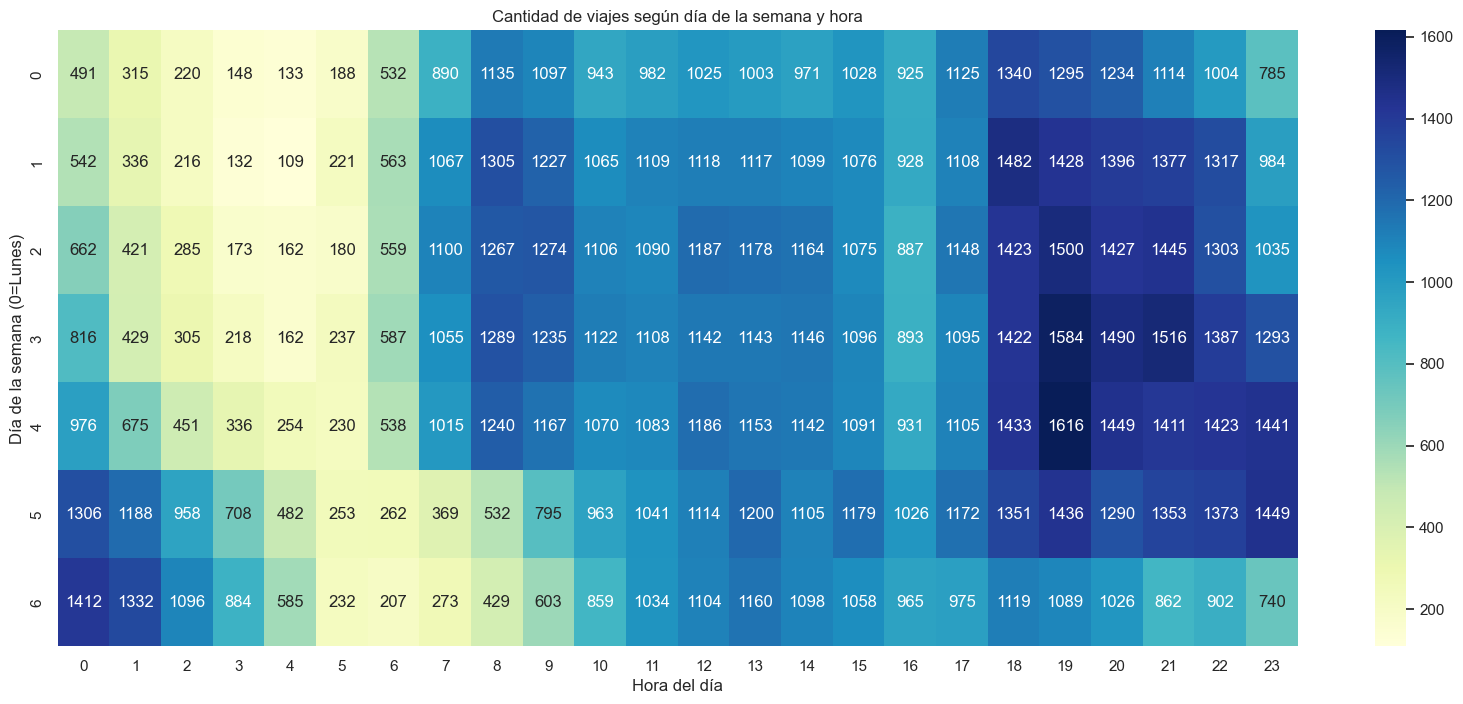

In [118]:
# Heatmap hora vs día de la semana

pivot_data = X_train.groupby(['day_week_num','hora']).size().unstack(fill_value=0)
plt.figure(figsize=(20,8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Cantidad de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

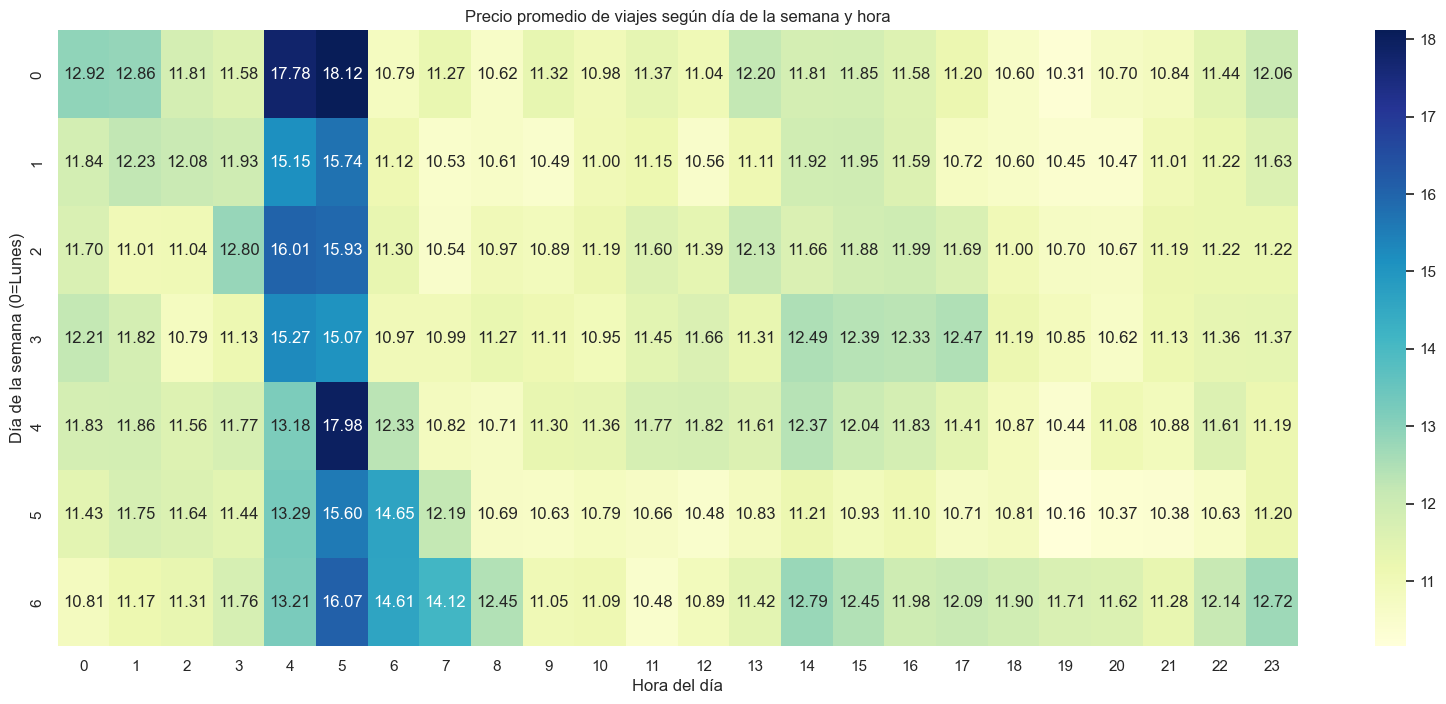

In [119]:
# Heatmap precio promedio vs día de la semana y hora

# Combinar X_train y y_train
data_combined = X_train[['day_week_num', 'hora']].copy()
data_combined['target'] = y_train

# Agrupar por día de la semana y hora, y calcular el precio promedio
pivot_data = data_combined.groupby(['day_week_num', 'hora'])['target'].mean().unstack(fill_value=0)

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Precio promedio de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

In [120]:
X_train

,key,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,day_week_num,day_week_num_sin,day_week_num_cos,hora,period_of_the_day,hora_sin,hora_cos
153248,17778666,2009-11-19 21:59:00+00:00,1,-73.978585,40.748388,-73.976913,40.784958,4.068841,3,0.433884,-0.900969,21,Noche,-0.707107,0.707107
67802,54334677,2013-02-27 22:29:15+00:00,1,-73.978198,40.752533,-73.909752,40.874372,14.721602,2,0.974928,-0.222521,22,Noche,-0.500000,0.866025
148889,11815656,2014-06-01 08:48:00+00:00,1,-73.994242,40.751227,-73.999432,40.762037,1.279042,6,-0.781831,0.623490,8,Mañana,0.866025,-0.500000
103093,28734805,2010-07-10 23:10:00+00:00,2,-73.951705,40.778330,-73.956050,40.777560,0.375743,5,-0.974928,-0.222521,23,Noche,-0.258819,0.965926
104681,54482655,2013-09-29 13:36:00+00:00,1,-73.989120,40.736932,-73.782890,40.643947,20.229724,6,-0.781831,0.623490,13,Tarde,-0.258819,-0.965926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,1659846,2011-02-24 17:50:00+00:00,1,-73.975727,40.755598,-73.972682,40.764690,1.043008,3,0.433884,-0.900969,17,Tarde,-0.965926,-0.258819
103694,1041443,2013-10-06 19:53:00+00:00,2,-73.987458,40.750500,-73.983002,40.743627,0.851456,6,-0.781831,0.623490,19,Noche,-0.965926,0.258819
131932,53427452,2012-04-21 13:51:00+00:00,1,-73.992855,40.758665,-74.001943,40.734407,2.803914,5,-0.974928,-0.222521,13,Tarde,-0.258819,-0.965926
146867,50554992,2009-09-01 19:39:00+00:00,5,-73.960555,40.757512,-73.958520,40.766328,0.995166,1,0.781831,0.623490,19,Noche,-0.965926,0.258819


In [121]:
X_train = X_train.drop('key', axis=1)
X_test = X_test.drop('key', axis=1)
X_train = X_train.drop('pickup_datetime', axis=1)
X_test = X_test.drop('pickup_datetime', axis=1)
X_train = X_train.drop('period_of_the_day', axis=1)
X_test = X_test.drop('period_of_the_day', axis=1)

In [122]:
# Escalado robusto para características numéricas
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [123]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [124]:
# Predicciones sobre el conjunto de entrenamiento
y_pred_train = model_lr.predict(X_train_scaled)

# Métricas
mse_train_rl = mean_squared_error(y_train, y_pred_train)
rmse_train_rl = math.sqrt(mse_train_rl)
r2_train_rl = r2_score(y_train, y_pred_train)

print("Métricas en el conjunto de entrenamiento:")
print(f'Error Cuadrático Medio: {round(mse_train_rl, 3)}')
print(f'Raíz Error Cuadrático Medi: {round(rmse_train_rl, 3)}')
print(f'Coeficiente de Determinación: {round(r2_train_rl, 3)}')

Métricas en el conjunto de entrenamiento:
Error Cuadrático Medio: 27.567
Raíz Error Cuadrático Medi: 5.25
Coeficiente de Determinación: 0.711


In [125]:
# Predicciones sobre el conjunto de test
y_pred = model_lr.predict(X_test_scaled)

# Métricas
mse_test_rl = mean_squared_error(y_test, y_pred)
rmse_test_rl = math.sqrt(mse_test_rl)
r2_test_rl = r2_score(y_test, y_pred)

print("\nMétricas en el conjunto de testeo:")
print(f'Error Cuadrático Medio: {round(mse_test_rl, 3)}')
print(f'Raíz Error Cuadrático Medio: {round(rmse_test_rl, 3)}')
print(f'Coeficiente de Determinación: {round(r2_test_rl, 3)}')


Métricas en el conjunto de testeo:
Error Cuadrático Medio: 37.093
Raíz Error Cuadrático Medio: 6.09
Coeficiente de Determinación: 0.646


In [126]:
# Coeficientes de la recta de regresión
intercepto = model_lr.intercept_
print(f"Intercepto: {intercepto}")
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': model_lr.coef_.flatten()}
                  )

df_coeficientes[df_coeficientes.coef != 0]

Intercepto: 8.859731784961465


,predictor,coef
0,passenger_count,0.036883
1,pickup_longitude,0.426463
2,pickup_latitude,0.040929
3,dropoff_longitude,-0.031883
4,dropoff_latitude,-0.622708
5,distance_km,5.839794
6,day_week_num,0.015697
7,day_week_num_sin,0.255366
8,day_week_num_cos,-0.382387
9,hora,-0.059360


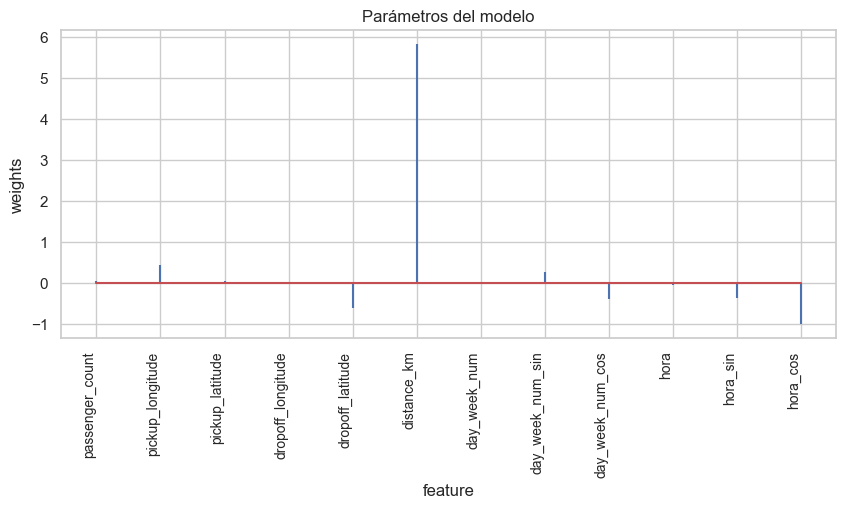

In [127]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame({'predictor': X_train.columns, 'coef': df_coeficientes.coef})

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo')
plt.show()

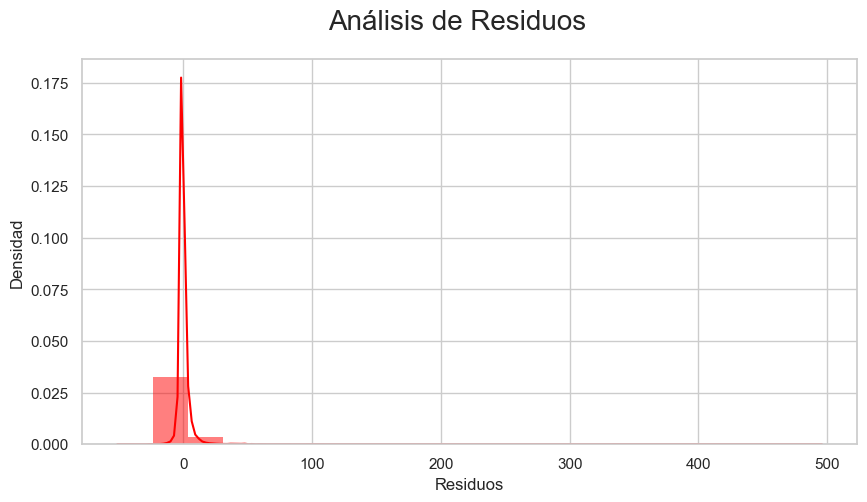

In [128]:
# Análisis de Residuos
fig = plt.figure(figsize=(10,5))

sns.histplot((y_test - y_pred), color="red", kde=True, stat="density", linewidth=0, bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)
plt.xlabel('Residuos')
plt.ylabel('Densidad')
plt.show()

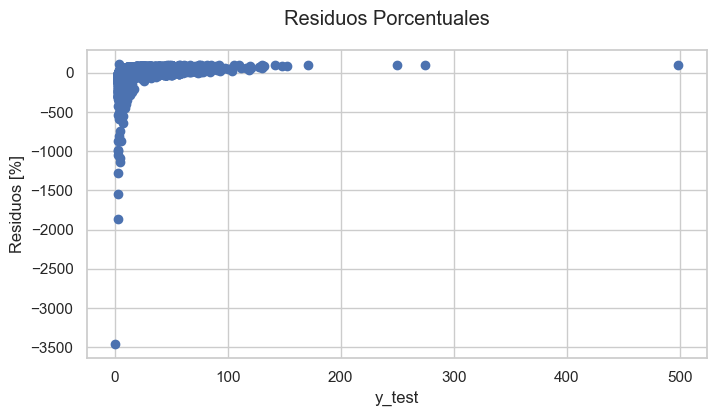

In [129]:
fig = plt.figure(figsize=(8,4))
fig.suptitle('Residuos Porcentuales')
plt.xlabel('y_test')
plt.ylabel('Residuos [%]')
plt.scatter(y_test,100*(y_test-y_pred)/y_test)
plt.show()

# Gradiente descendiente


In [130]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_val = pxm
        y_test = px1
        W = mx1
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

In [131]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)



    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

In [132]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

In [133]:
# Agregar arriba de todo
X_train_gd, X_val_gd, y_train_gd, y_val_gd = train_test_split(X_train_scaled, y_train, test_size=0.125, random_state=42)

In [134]:
X_train_scaled.shape, X_val_gd.shape, X_train_gd.shape

((158431, 12), (19804, 12), (138627, 12))

In [135]:
# Convertir a numpy arrays y asegurar shapes correctos
X_train_gd = np.array(X_train_gd)  # Shape: (135485, 13)
X_val_gd = np.array(X_val_gd)      # Shape: (19355, 13)
y_train_gd = np.array(y_train_gd).reshape(-1, 1)  # Shape: (135485, 1)
y_val_gd = np.array(y_val_gd).reshape(-1, 1)      # Shape: (19355, 1)
X_test_scaled = np.array(X_test_scaled)    # Shape: (38710, 13)
y_test = np.array(y_test).reshape(-1, 1)    # Shape: (38710, 1)

In [136]:
# Verificar shapes
print("Shapes después de conversión:")
print(f"X_train: {X_train_gd.shape}")
print(f"X_val: {X_val_gd.shape}")
print(f"y_train: {y_train_gd.shape}")
print(f"y_val: {y_val_gd.shape}")

Shapes después de conversión:
X_train: (138627, 12)
X_val: (19804, 12)
y_train: (138627, 1)
y_val: (19804, 1)


## Gradiente Descendiente Convencional

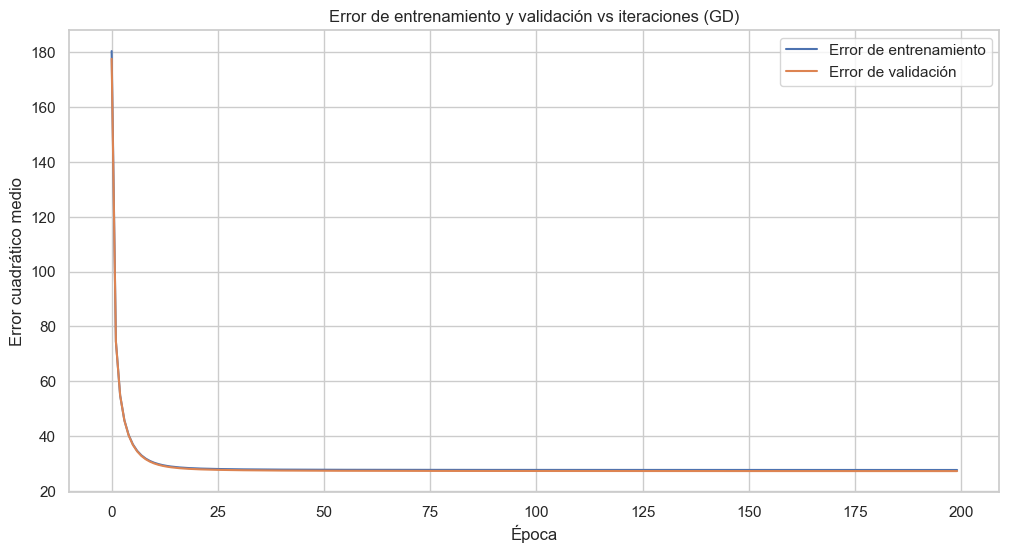

In [137]:
# Ahora llamar a la función
W = gradient_descent(X_train_gd, y_train_gd, X_val_gd, y_val_gd, lr=0.1, epochs=200)

## Gradiente Descendiente Estocastico

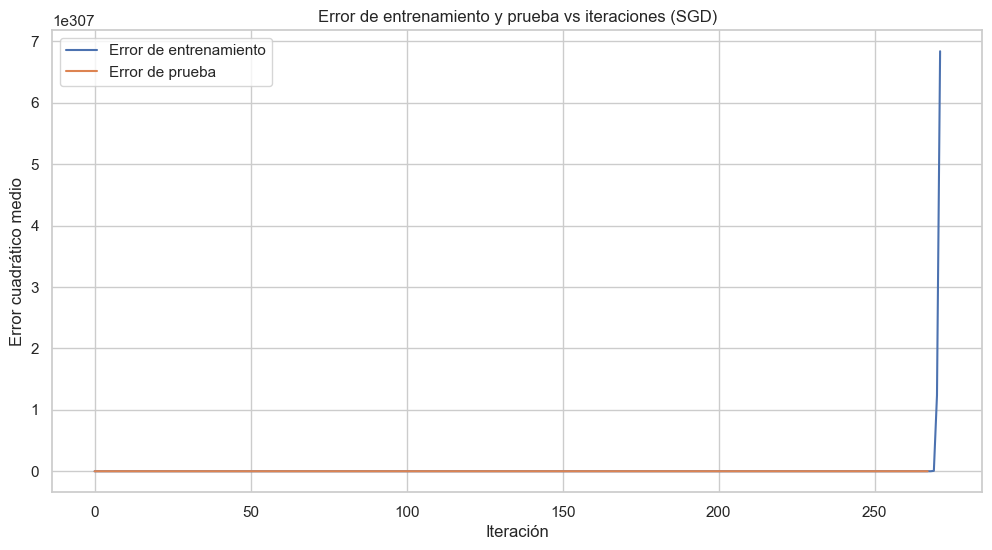

array([[nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan]])

In [138]:
stochastic_gradient_descent(X_train_gd, y_train_gd, X_val_gd, y_val_gd, lr=1, epochs=2)
# epoch 1 = 8.5s

## Gradiente Descendiente Mini Batch

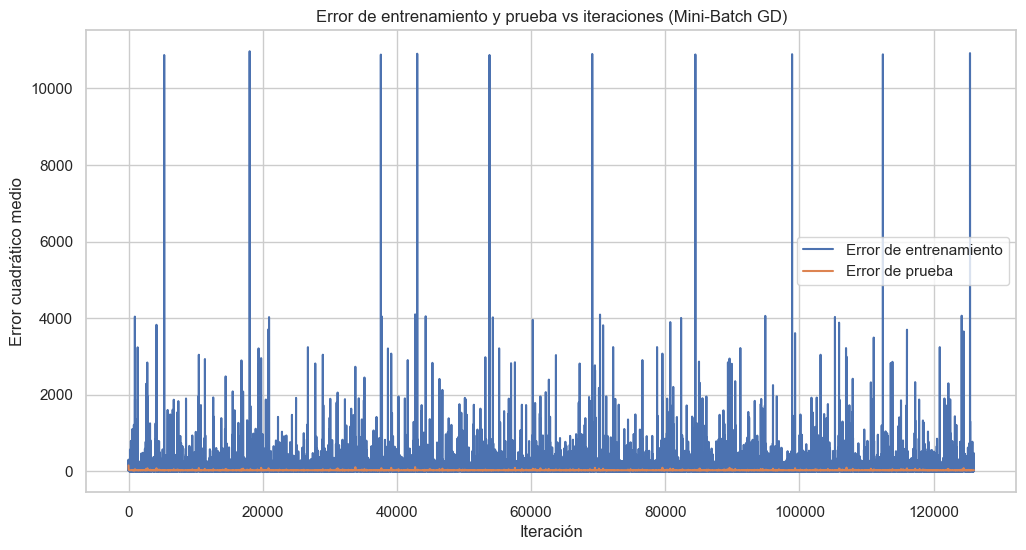

array([[ 8.91317382],
       [-0.24982772],
       [ 0.5787659 ],
       [ 0.25587217],
       [-0.13155357],
       [-0.18838801],
       [ 5.69485419],
       [-0.05521409],
       [ 0.24208379],
       [-0.41378214],
       [-0.02933633],
       [-0.09132768],
       [-1.05388747]])

In [139]:
mini_batch_gradient_descent(X_train_gd, y_train_gd, X_val_gd, y_val_gd, epochs=10)
# epochs=200 llego a 3min

# Regularizacion

## Lasso

In [140]:
# Lasso con alpha=0.1
lasso = Lasso(alpha=0.1, max_iter=1000, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Predicciones sobre el conjunto de entrenamiento
y_pred_train_lasso = lasso.predict(X_train_scaled)

# Métricas de entrenamiento
mse_train_lasso = mean_squared_error(y_train, y_pred_train_lasso)
rmse_train_lasso = math.sqrt(mse_train_lasso)
r2_train_lasso = r2_score(y_train, y_pred_train_lasso)

print("RESULTADOS DEL MODELO LASSO:")

print(f"\nMÉTRICAS EN ENTRENAMIENTO:")
print(f"  Error Cuadrático Medio (MSE): {mse_train_lasso:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_train_lasso:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_lasso:.3f}")

RESULTADOS DEL MODELO LASSO:

MÉTRICAS EN ENTRENAMIENTO:
  Error Cuadrático Medio (MSE): 27.698
  Raíz del Error Cuadrático (RMSE): 5.263
  Coeficiente de Determinación (R²): 0.709


In [141]:
# Predicciones sobre el conjunto de test
y_pred_test_lasso = lasso.predict(X_test_scaled)

# Métricas de test
mse_test_lasso = mean_squared_error(y_test, y_pred_test_lasso)
rmse_test_lasso = math.sqrt(mse_test_lasso)
r2_test_lasso = r2_score(y_test, y_pred_test_lasso)

print(f"\nMÉTRICAS EN TEST:")
print(f"  Error Cuadrático Medio (MSE): {mse_test_lasso:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_test_lasso:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_lasso:.3f}")


MÉTRICAS EN TEST:
  Error Cuadrático Medio (MSE): 37.182
  Raíz del Error Cuadrático (RMSE): 6.098
  Coeficiente de Determinación (R²): 0.646


In [142]:
# Mostrar coeficientes
print("\nCoeficientes del modelo Lasso:")
print(lasso.coef_)
print(lasso.score(X_train_scaled,y_train))


Coeficientes del modelo Lasso:
[ 0.          0.39988007 -0.         -0.         -0.48953514  5.77799575
 -0.          0.         -0.          0.         -0.         -0.5417575 ]
0.7092244965338461


## Ridge

In [143]:
# Ridge con alpha=0.1
ridge = Ridge(alpha=0.1, max_iter=1000, random_state=42)
ridge.fit(X_train_scaled, y_train)

# Predicciones sobre el conjunto de entrenamiento
y_pred_train_ridge = ridge.predict(X_train_scaled)

# Métricas de entrenamiento
mse_train_ridge = mean_squared_error(y_train, y_pred_train_ridge)
rmse_train_ridge = math.sqrt(mse_train_ridge)
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)

print("RESULTADOS DEL MODELO RIDGE")

print(f"\nMÉTRICAS EN ENTRENAMIENTO:")
print(f"  Error Cuadrático Medio (MSE): {mse_train_ridge:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_train_ridge:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_ridge:.3f}")

RESULTADOS DEL MODELO RIDGE

MÉTRICAS EN ENTRENAMIENTO:
  Error Cuadrático Medio (MSE): 27.567
  Raíz del Error Cuadrático (RMSE): 5.250
  Coeficiente de Determinación (R²): 0.711


In [144]:
# Predicciones sobre el conjunto de test
y_pred_test_ridge = ridge.predict(X_test_scaled)

# Métricas de test
mse_test_ridge = mean_squared_error(y_test, y_pred_test_ridge)
rmse_test_ridge = math.sqrt(mse_test_ridge)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)

print(f"\nMÉTRICAS EN TEST:")
print(f"  Error Cuadrático Medio (MSE): {mse_test_ridge:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_test_ridge:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_ridge:.3f}")


MÉTRICAS EN TEST:
  Error Cuadrático Medio (MSE): 37.093
  Raíz del Error Cuadrático (RMSE): 6.090
  Coeficiente de Determinación (R²): 0.646


In [145]:
# Mostrar coeficientes
print("\nCoeficientes del modelo Ridge:")
print(ridge.coef_)
print(ridge.score(X_train_scaled, y_train))


Coeficientes del modelo Ridge:
[ 0.03688251  0.42646352  0.04092784 -0.03188254 -0.62270819  5.83979121
  0.01569668  0.25536508 -0.38238597 -0.05935883 -0.37307079 -0.99296169]
0.7106025472945074


## Elastic Net

In [146]:
# Elastic Net con alpha=0.1 y l1_ratio=0.5
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=1000, random_state=42)
elasticnet.fit(X_train_scaled, y_train)

# Predicciones sobre el conjunto de entrenamiento
y_pred_train_en = elasticnet.predict(X_train_scaled)

# Métricas de entrenamiento
mse_train_en = mean_squared_error(y_train, y_pred_train_en)
rmse_train_en = math.sqrt(mse_train_en)
r2_train_en = r2_score(y_train, y_pred_train_en)

print("RESULTADOS DEL MODELO Elastic Net")

print(f"\nMÉTRICAS EN ENTRENAMIENTO:")
print(f"  Error Cuadrático Medio (MSE): {mse_train_en:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_train_en:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_en:.3f}")

RESULTADOS DEL MODELO Elastic Net

MÉTRICAS EN ENTRENAMIENTO:
  Error Cuadrático Medio (MSE): 27.719
  Raíz del Error Cuadrático (RMSE): 5.265
  Coeficiente de Determinación (R²): 0.709


In [147]:
# Predicciones sobre el conjunto de test
y_pred_test_en = elasticnet.predict(X_test_scaled)

# Métricas de test
mse_test_en = mean_squared_error(y_test, y_pred_test_en)
rmse_test_en = math.sqrt(mse_test_en)
r2_test_en = r2_score(y_test, y_pred_test_en)

print(f"\nMÉTRICAS EN TEST:")
print(f"  Error Cuadrático Medio (MSE): {mse_test_en:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_test_en:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_en:.3f}")


MÉTRICAS EN TEST:
  Error Cuadrático Medio (MSE): 37.212
  Raíz del Error Cuadrático (RMSE): 6.100
  Coeficiente de Determinación (R²): 0.645


# Comparar modelos

In [ ]:
# Crear DataFrame de comparación
comparison_data = {
    'Modelo': ['Regresión Lineal', 'Lasso', 'Ridge', 'Elastic Net'],
    'MSE_Train': [mse_train_rl, mse_train_lasso, mse_train_ridge, mse_train_en],
    'RMSE_Train': [rmse_train_rl, rmse_train_lasso, rmse_train_ridge, rmse_train_en],
    'R2_Train': [r2_train_rl, r2_train_lasso, r2_train_ridge, r2_train_en],
    'MSE_Test': [mse_test_rl, mse_test_lasso, mse_test_ridge, mse_test_en],
    'RMSE_Test': [rmse_test_rl, rmse_test_lasso, rmse_test_ridge, rmse_test_en],
    'R2_Test': [r2_test_rl, r2_test_lasso, r2_test_ridge, r2_test_en]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("TABLA COMPARATIVA DE MODELOS")
print(comparison_df.to_string(index=False))

TABLA COMPARATIVA DE MODELOS
          Modelo  MSE_Train  RMSE_Train  R2_Train  MSE_Test  RMSE_Test  R2_Test
Regresión Lineal    27.5671      5.2504    0.7106   37.0925     6.0904   0.6464
           Lasso    27.6984      5.2629    0.7092   37.1823     6.0977   0.6456
           Ridge    27.5671      5.2504    0.7106   37.0925     6.0904   0.6464
     Elastic Net    27.7192      5.2649    0.7090   37.2123     6.1002   0.6453
